In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("Ready")


Ready


In [2]:
# Core strategy asset
spy_raw = yf.download("SPY", start="2018-01-01",
                       end="2024-01-01", auto_adjust=True)
spy_raw.columns = spy_raw.columns.get_level_values(0)
spy = spy_raw["Close"].squeeze()

# BTC satellite
btc_raw = yf.download("BTC-USD", start="2018-01-01",
                       end="2024-01-01", auto_adjust=True)
btc_raw.columns = btc_raw.columns.get_level_values(0)
btc = btc_raw["Close"].squeeze()

# Multi-asset diversifier universe
multi_tickers = ["SPY", "EFA", "AGG", "GLD", "VNQ"]
multi_raw = yf.download(multi_tickers, start="2018-01-01",
                         end="2024-01-01", auto_adjust=True)
multi_prices = multi_raw["Close"]
multi_prices.columns = multi_prices.columns.get_level_values(0)
multi_prices = multi_prices.dropna()

print(f"SPY: {len(spy)} days")
print(f"BTC: {len(btc)} days")
print(f"Multi-asset: {len(multi_prices)} days, {multi_prices.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  5 of 5 completed


SPY: 1509 days
BTC: 2191 days
Multi-asset: 1509 days, ['AGG', 'EFA', 'GLD', 'SPY', 'VNQ']


In [3]:
# ── STRATEGY 1: SMA + RSI2 + Vol Targeting on SPY ───────
spy_ret = np.log(spy / spy.shift(1)).dropna()
sma50   = spy.rolling(50).mean()
sma200  = spy.rolling(200).mean()
sma_sig = (sma50 > sma200).astype(int).shift(1).fillna(0)

rsi2 = compute_rsi(spy, period=2)
pos_list, cp = [], 0
for i in range(len(rsi2)):
    in_up = spy.iloc[i] > sma200.iloc[i]
    if cp == 0 and rsi2.iloc[i] < 10 and in_up:
        cp = 1
    elif cp == 1 and (rsi2.iloc[i] > 90 or not in_up):
        cp = 0
    pos_list.append(cp)
rsi2_sig = pd.Series(pos_list,
                      index=spy.index).shift(1).fillna(0)

rv1      = spy_ret.rolling(20).std() * np.sqrt(252)
vs1      = (0.10 / rv1).clip(0, 1)
pos1     = sma_sig.reindex(spy_ret.index).fillna(0)
pos1     = pos1.where(
    rsi2_sig.reindex(spy_ret.index).fillna(0)==0, 1.0)
tr1      = pos1.diff().abs().fillna(0)
strat1   = pos1 * spy_ret * vs1.shift(1).fillna(1) - tr1*0.0006

# ── STRATEGY 2: BTC SMA + Vol Targeting ──────────────────
btc_ret = np.log(btc / btc.shift(1)).dropna()
b50     = btc.rolling(50).mean()
b200    = btc.rolling(200).mean()
bpos    = (b50 > b200).astype(int).shift(1).fillna(0)
bpos    = bpos.reindex(btc_ret.index).fillna(0)
btr     = bpos.diff().abs().fillna(0)
brv     = btc_ret.rolling(20).std() * np.sqrt(365)
bvs     = (0.20 / brv).clip(0, 1)
strat2  = bpos * btc_ret * bvs.shift(1).fillna(1) - btr*0.001

# ── STRATEGY 3: Equal Weight Multi-Asset ─────────────────
multi_ret = multi_prices.pct_change().dropna()
strat3    = multi_ret.mean(axis=1)  # equal weight daily ret

# Common date index
common_idx = strat1.index.intersection(
             strat2.index.intersection(strat3.index))

s1 = strat1.reindex(common_idx).fillna(0)
s2 = strat2.reindex(common_idx).fillna(0)
s3 = strat3.reindex(common_idx).fillna(0)

print(f"Common period: {common_idx[0].date()} to {common_idx[-1].date()}")
print(f"Observations : {len(common_idx)}")
print(f"\nIndividual Sharpes:")

def sharpe(r, days=252):
    ar = r.mean() * days
    av = r.std()  * np.sqrt(days)
    return (ar - 0.02) / av if av > 0 else 0

print(f"  Strategy 1 (SMA+RSI2+VolTgt) : {sharpe(s1):.2f}")
print(f"  Strategy 2 (BTC SMA+VolTgt)  : {sharpe(s2):.2f}")
print(f"  Strategy 3 (Equal Weight ETF): {sharpe(s3):.2f}")


Common period: 2018-01-03 to 2023-12-29
Observations : 1508

Individual Sharpes:
  Strategy 1 (SMA+RSI2+VolTgt) : 0.50
  Strategy 2 (BTC SMA+VolTgt)  : 0.09
  Strategy 3 (Equal Weight ETF): 0.41


In [4]:
# Check correlation between strategies first
corr = pd.DataFrame({"S1_SPY": s1, "S2_BTC": s2,
                      "S3_Multi": s3}).corr()
print("Strategy Correlation Matrix:")
print(corr.round(3).to_string())

# Combine with weights
# Core: 60% SPY strategy, Satellite: 15% BTC, Diversifier: 25%
w1, w2, w3 = 0.60, 0.15, 0.25
portfolio   = w1*s1 + w2*s2 + w3*s3

# Buy and hold SPY benchmark
bh = spy_ret.reindex(common_idx).fillna(0)

def perf(r, name, days=252):
    ar = r.mean() * days
    av = r.std()  * np.sqrt(days)
    sh = (ar - 0.02) / av if av > 0 else 0
    w  = (1 + r).cumprod()
    dd = ((w - w.cummax()) / w.cummax()).min()
    return {"name": name, "ar": ar, "av": av,
            "sh": sh, "dd": dd, "eq": w}

results = [
    perf(portfolio, "Final Portfolio (60/15/25)"),
    perf(s1,        "Strategy 1 SPY only"),
    perf(s2,        "Strategy 2 BTC only"),
    perf(s3,        "Strategy 3 Multi-Asset"),
    perf(bh,        "Buy & Hold SPY"),
]

print(f"\n{'='*68}")
print(f"  FINAL PORTFOLIO — PERFORMANCE COMPARISON")
print(f"{'='*68}")
print(f"  {'Strategy':<30} {'Ann Ret':>8} {'Ann Vol':>8} "
      f"{'Sharpe':>7} {'Max DD':>9}")
print(f"  {'-'*63}")
for r in results:
    print(f"  {r['name']:<30} {r['ar']:>8.2%} {r['av']:>8.2%} "
          f"{r['sh']:>7.2f} {r['dd']:>9.2%}")
print(f"{'='*68}")

Strategy Correlation Matrix:
          S1_SPY  S2_BTC  S3_Multi
S1_SPY     1.000   0.207     0.551
S2_BTC     0.207   1.000     0.223
S3_Multi   0.551   0.223     1.000

  FINAL PORTFOLIO — PERFORMANCE COMPARISON
  Strategy                        Ann Ret  Ann Vol  Sharpe    Max DD
  ---------------------------------------------------------------
  Final Portfolio (60/15/25)        6.08%    8.34%    0.49   -15.41%
  Strategy 1 SPY only               6.24%    8.53%    0.50   -11.82%
  Strategy 2 BTC only               3.49%   16.48%    0.09   -34.87%
  Strategy 3 Multi-Asset            7.22%   12.85%    0.41   -23.81%
  Buy & Hold SPY                   11.21%   20.47%    0.45   -35.75%


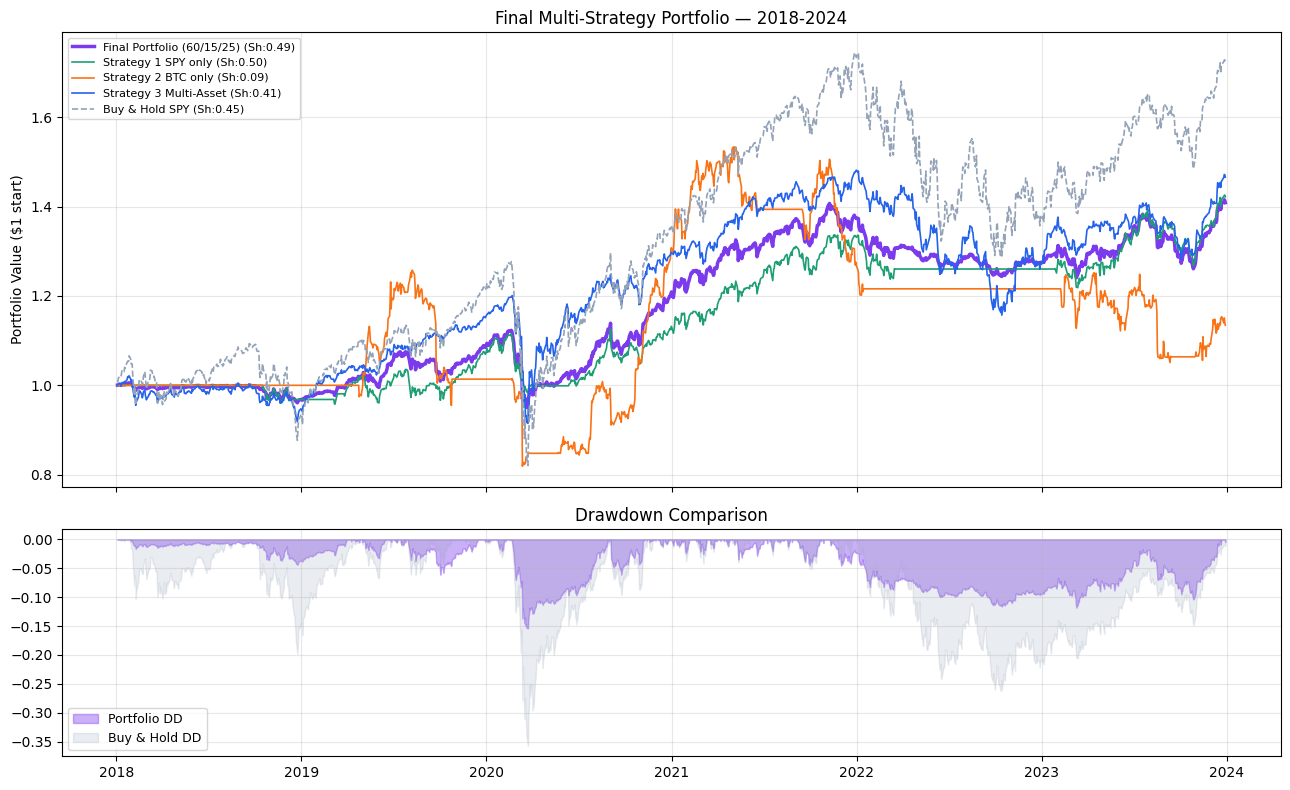


PORTFOLIO WEIGHT ANALYSIS
  Strategy 1 (SMA+RSI2+VolTgt): 60% weight
  Strategy 2 (BTC SMA+VolTgt) : 15% weight
  Strategy 3 (Equal Wt ETF)   : 25% weight
  Portfolio vs Buy & Hold:
  Sharpe improvement : +0.04
  Drawdown reduction : +20.34%


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

colors = {'Final Portfolio (60/15/25)': '#7c3aed',
          'Strategy 1 SPY only'       : '#1D9E75',
          'Strategy 2 BTC only'       : '#f97316',
          'Strategy 3 Multi-Asset'    : '#2563eb',
          'Buy & Hold SPY'            : '#94a3b8'}

for r in results:
    style = '--' if r['name'] == 'Buy & Hold SPY' else '-'
    lw    = 2.5 if r['name'] == 'Final Portfolio (60/15/25)' else 1.2
    ax1.plot(r['eq'], color=colors[r['name']],
             lw=lw, linestyle=style,
             label=f"{r['name']} (Sh:{r['sh']:.2f})")

ax1.set_title('Final Multi-Strategy Portfolio — 2018-2024')
ax1.set_ylabel('Portfolio Value ($1 start)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Portfolio drawdown
port_eq = (1 + portfolio).cumprod()
port_dd = (port_eq - port_eq.cummax()) / port_eq.cummax()
bh_dd   = (results[-1]['eq'] - results[-1]['eq'].cummax()) / \
            results[-1]['eq'].cummax()

ax2.fill_between(port_dd.index, port_dd, 0,
                  color='#7c3aed', alpha=0.4,
                  label='Portfolio DD')
ax2.fill_between(bh_dd.index, bh_dd, 0,
                  color='#94a3b8', alpha=0.2,
                  label='Buy & Hold DD')
ax2.set_title('Drawdown Comparison')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Strategy weight contribution analysis
print(f"\nPORTFOLIO WEIGHT ANALYSIS")
print(f"{'='*45}")
print(f"  Strategy 1 (SMA+RSI2+VolTgt): {w1:.0%} weight")
print(f"  Strategy 2 (BTC SMA+VolTgt) : {w2:.0%} weight")
print(f"  Strategy 3 (Equal Wt ETF)   : {w3:.0%} weight")
print(f"{'='*45}")
print(f"  Portfolio vs Buy & Hold:")
print(f"  Sharpe improvement : {results[0]['sh']-results[-1]['sh']:+.2f}")
print(f"  Drawdown reduction : {results[0]['dd']-results[-1]['dd']:+.2%}")